# Enhanced Clinical Data Analysis for Mortality Prediction

This notebook provides a comprehensive analysis of ICU patient data to predict mortality, including advanced visualization, model explanations, and fairness evaluations.

## 1. Setup and Configuration

In [7]:
# Import standard libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import custom modules
import data_processing as dp
import visualization as viz
import modeling as mdl
import utils
import config

# Import additional libraries for explainability
import shap
from lime.lime_tabular import LimeTabularExplainer
# Fairness evaluation
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

# Import sklearn metrics
from sklearn.metrics import (classification_report, roc_auc_score, precision_recall_curve, 
                             roc_curve, confusion_matrix, auc, precision_score, recall_score, 
                             f1_score)

# Set visualization style
viz.set_visualization_style()
plt.style.use('seaborn-v0_8-whitegrid')

# Create directories if they don't exist
os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.MODELS_DIR, exist_ok=True)

## 2. Data Loading and Preprocessing

Number of samples	: 91713
Number of features	: 186


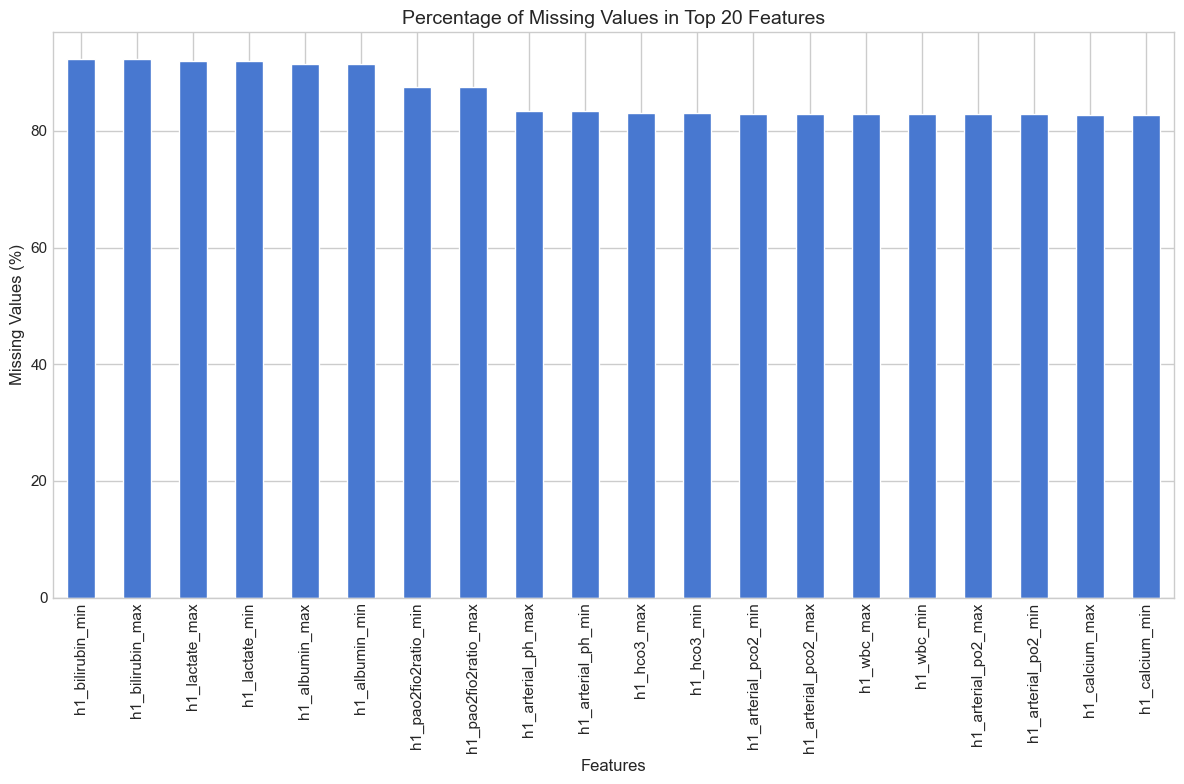

Training set size: (73370, 185)
Testing set size: (18343, 185)
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%
Number of columns with >80% missing values: 34
Number of numerical features: 143
Number of categorical features: 8


In [8]:
# Load data and data dictionary
df, description_dict = dp.load_data(config.DATA_DIR)
utils.print_dataset_info(df)

# Analyze missing values
missing_percentages, high_missing_cols = dp.analyze_missing_values(df)

# Plot missing values
plt.figure(figsize=(12, 8))
missing_percentages.sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Percentage of Missing Values in Top 20 Features', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Values (%)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Split data for modeling
X, y = dp.split_features_target(df, config.TARGET_COLUMN)
X_train, X_test, y_train, y_test = dp.create_train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

# Filter high missing columns and identify column types
X_train_filtered, X_test_filtered, high_missing_cols = dp.filter_high_missing_columns(
    X_train, X_test, threshold=config.MISSING_THRESHOLD_HIGH
)
numerical_cols, categorical_cols = dp.identify_column_types(X_train_filtered)

# Save processed data for later use
processed_data = {
    'X_train': X_train_filtered,
    'X_test': X_test_filtered,
    'y_train': y_train,
    'y_test': y_test,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'description_dict': description_dict
}

with open(os.path.join(config.RESULTS_DIR, 'processed_data.pkl'), 'wb') as f:
    pickle.dump(processed_data, f)

## 3. Enhanced Data Exploration

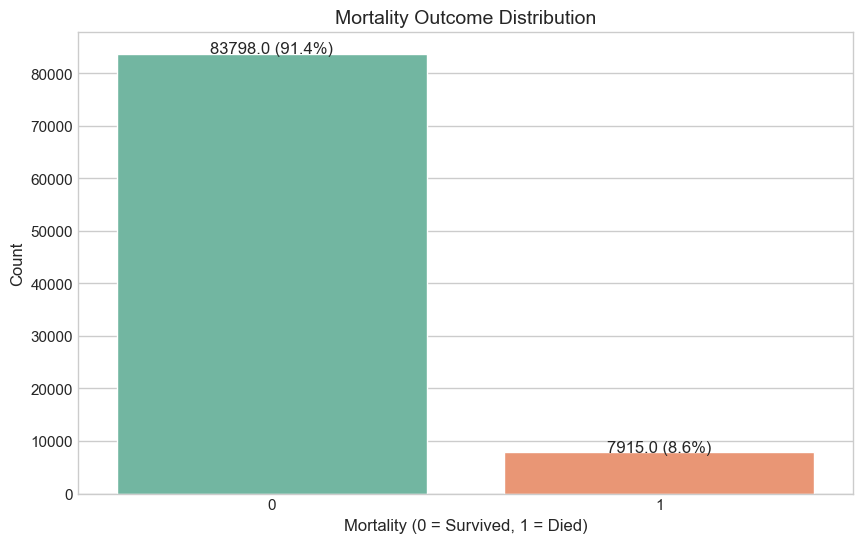

Dead: 7915 (8.63%) Survived: 83798 (91.37%) out of a total of 91713


In [9]:
# Visualize target variable distribution
plt.figure(figsize=(10, 6))
if 'hospital_death' in df.columns:
    ax = sns.countplot(x='hospital_death', data=df, palette="Set2")
    
    # Add count and percentage annotations
    total = len(df['hospital_death'])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 0.1,
                f'{height} ({height/total:.1%})',
                ha="center") 
    
    plt.title('Mortality Outcome Distribution', fontsize=14)
    plt.xlabel('Mortality (0 = Survived, 1 = Died)', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()
    
    # Calculate and display death toll
    number_of_deaths = np.sum(df['hospital_death'] == 1)
    number_of_survivors = np.sum(df['hospital_death'] == 0)
    print(f"Dead: {number_of_deaths} ({number_of_deaths/total:.2%}) Survived: {number_of_survivors} ({number_of_survivors/total:.2%}) out of a total of {total}")
else:
    print("Column 'hospital_death' not found in the dataset.")

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


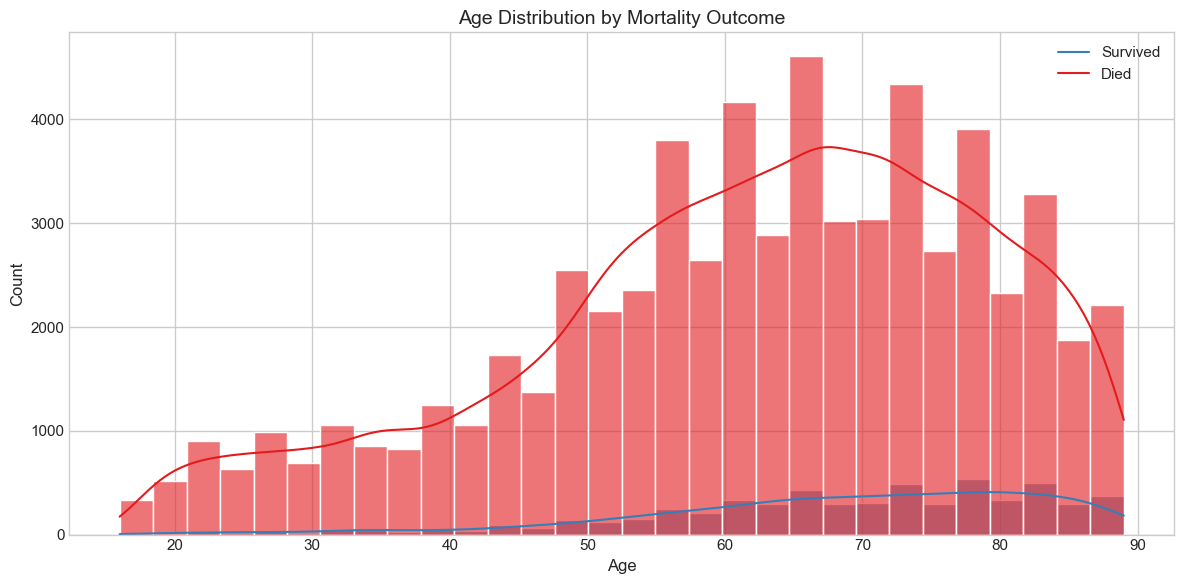

In [10]:
# Explore age distribution by mortality outcome (if available)
if 'age' in X_train_filtered.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=X_train_filtered.join(y_train), x='age', hue='hospital_death', 
                 bins=30, kde=True, palette='Set1', alpha=0.6)
    plt.title('Age Distribution by Mortality Outcome', fontsize=14)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(['Survived', 'Died'])
    plt.tight_layout()
    plt.show()

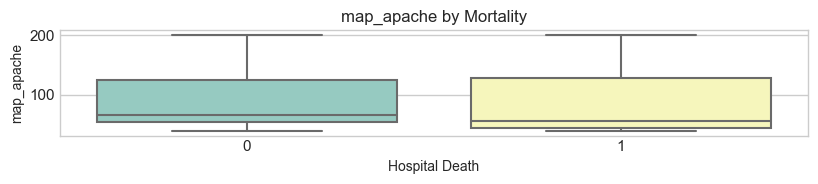

In [11]:
# Analyze key physiological parameters by mortality (select a few important ones)
physiological_vars = ['heart_rate', 'map_apache', 'resp_rate', 'temperature', 'wbc', 'creatinine']
available_vars = [var for var in physiological_vars if var in X_train_filtered.columns]

if available_vars:
    plt.figure(figsize=(16, 4 * len(available_vars) // 2))
    for i, var in enumerate(available_vars, 1):
        plt.subplot(len(available_vars) // 2 + len(available_vars) % 2, 2, i)
        try:
            sns.boxplot(x='hospital_death', y=var, data=X_train_filtered.join(y_train),
                        palette='Set3')
            plt.title(f'{var} by Mortality', fontsize=12)
            plt.xlabel('Hospital Death', fontsize=10)
            plt.ylabel(var, fontsize=10)
        except Exception as e:
            print(f"Error plotting {var}: {str(e)}")
    plt.tight_layout()
    plt.show()

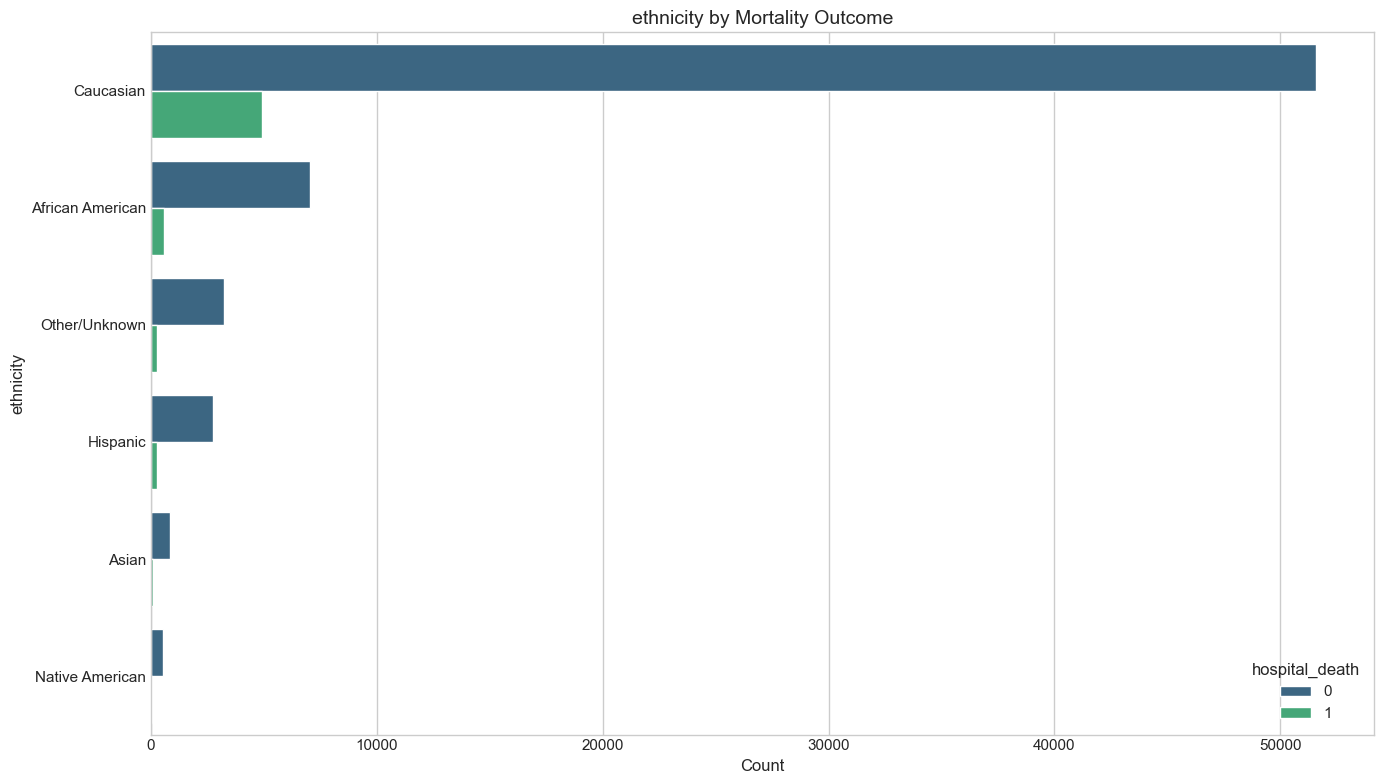

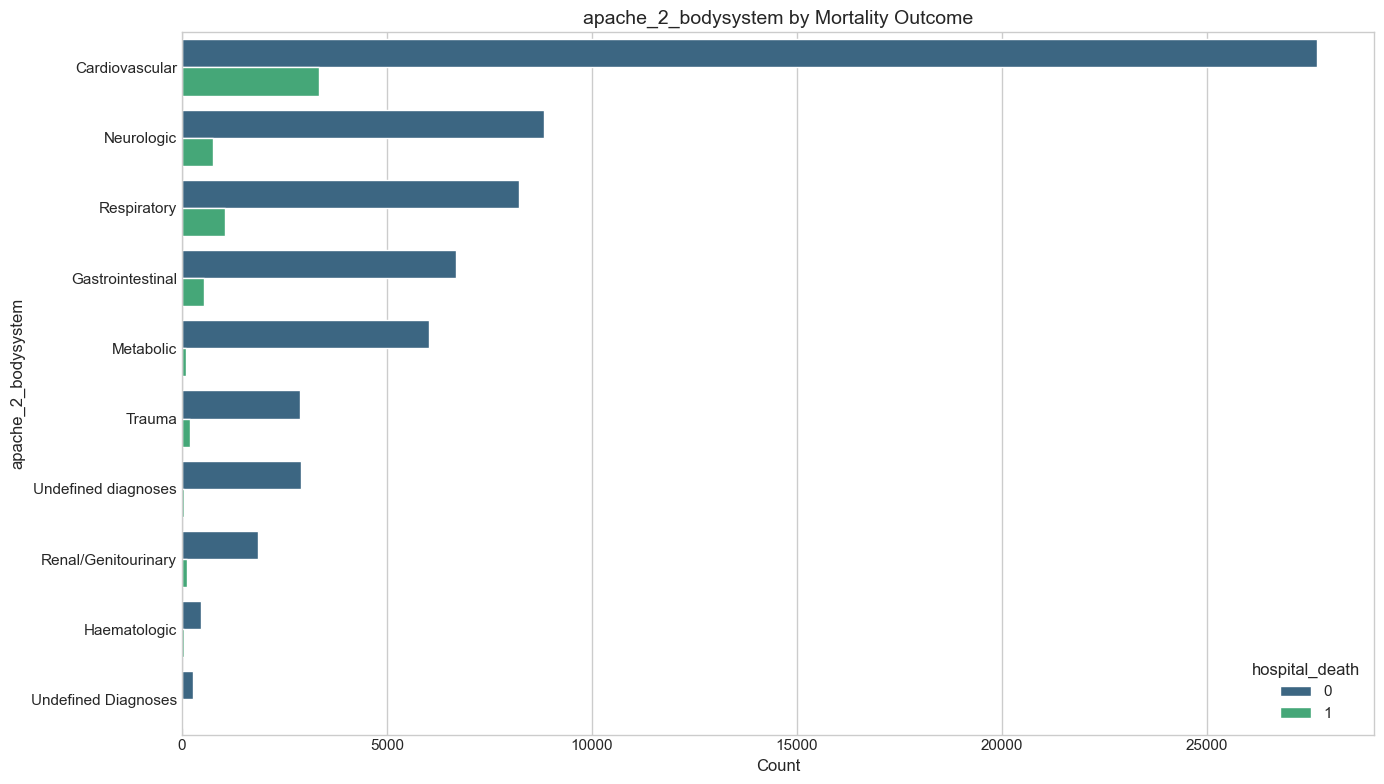

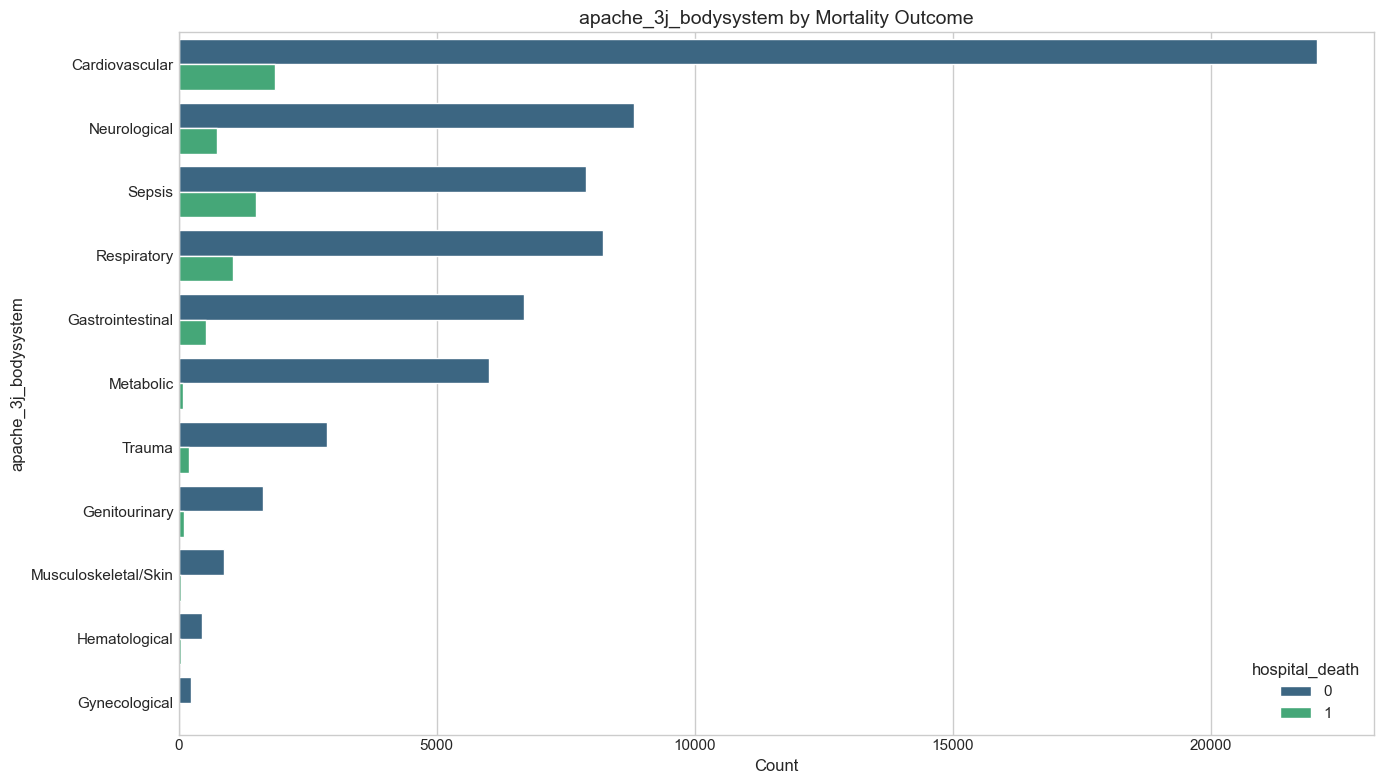

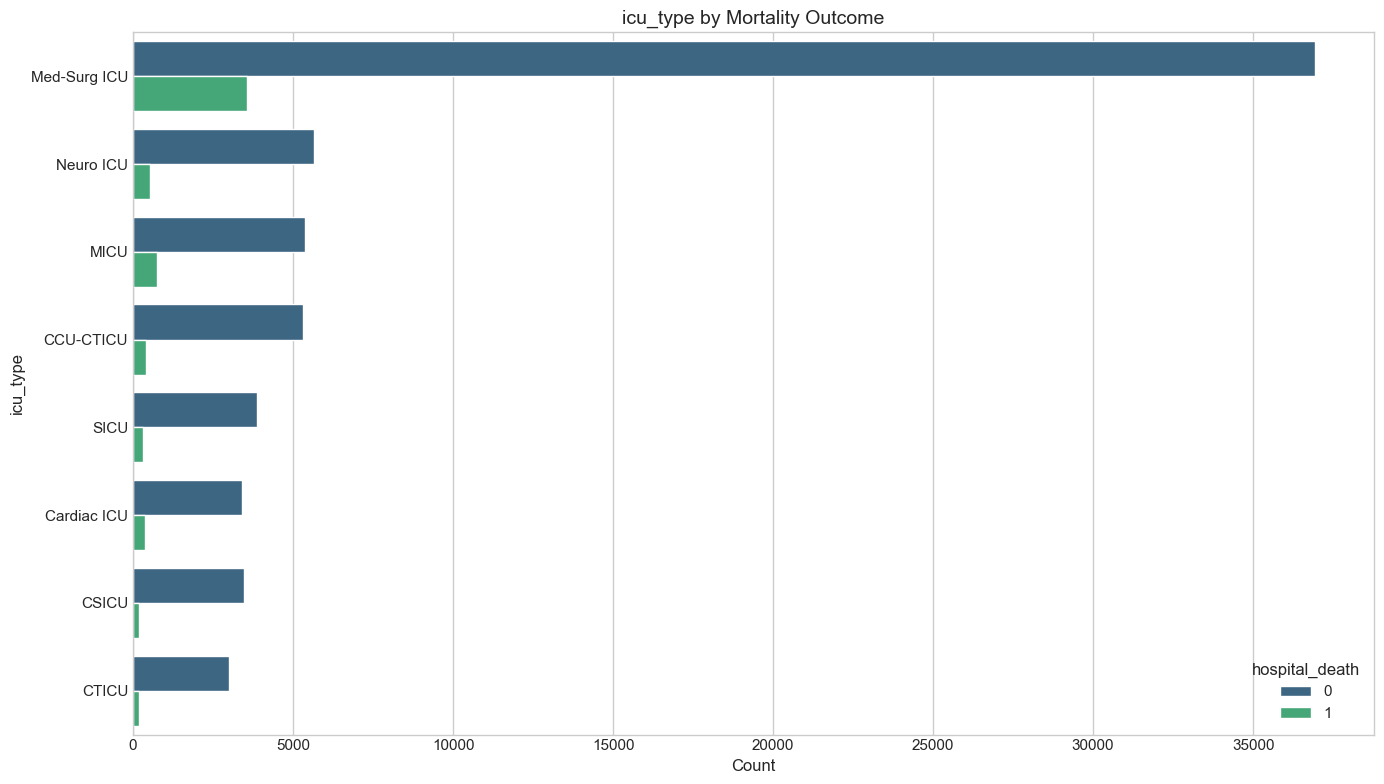

In [12]:
# Visualize categorical features
key_categorical = ['ethnicity', 'apache_2_bodysystem', 'apache_3j_bodysystem', 'icu_type']
available_categorical = [col for col in key_categorical if col in X_train_filtered.columns]

if available_categorical:
    for col in available_categorical:
        plt.figure(figsize=(14, 8))
        # Get value counts
        value_counts = X_train_filtered[col].value_counts()
        # Plot only top 15 categories if there are many
        if len(value_counts) > 15:
            top_categories = value_counts.index[:15].tolist()
            filtered_data = X_train_filtered[X_train_filtered[col].isin(top_categories)]
            filtered_y = y_train[filtered_data.index]
            
            # Create a countplot with percentages
            ax = sns.countplot(y=col, data=filtered_data.join(filtered_y), 
                              hue='hospital_death', palette='viridis',
                              order=value_counts.index[:15])
            plt.title(f'Top 15 Categories for {col} by Mortality Outcome', fontsize=14)
            plt.xlabel('Count', fontsize=12)
            plt.ylabel(col, fontsize=12)
        else:
            # Create a countplot for all categories
            ax = sns.countplot(y=col, data=X_train_filtered.join(y_train), 
                              hue='hospital_death', palette='viridis',
                              order=value_counts.index)
            plt.title(f'{col} by Mortality Outcome', fontsize=14)
            plt.xlabel('Count', fontsize=12)
            plt.ylabel(col, fontsize=12)
        
        plt.tight_layout()
        plt.show()

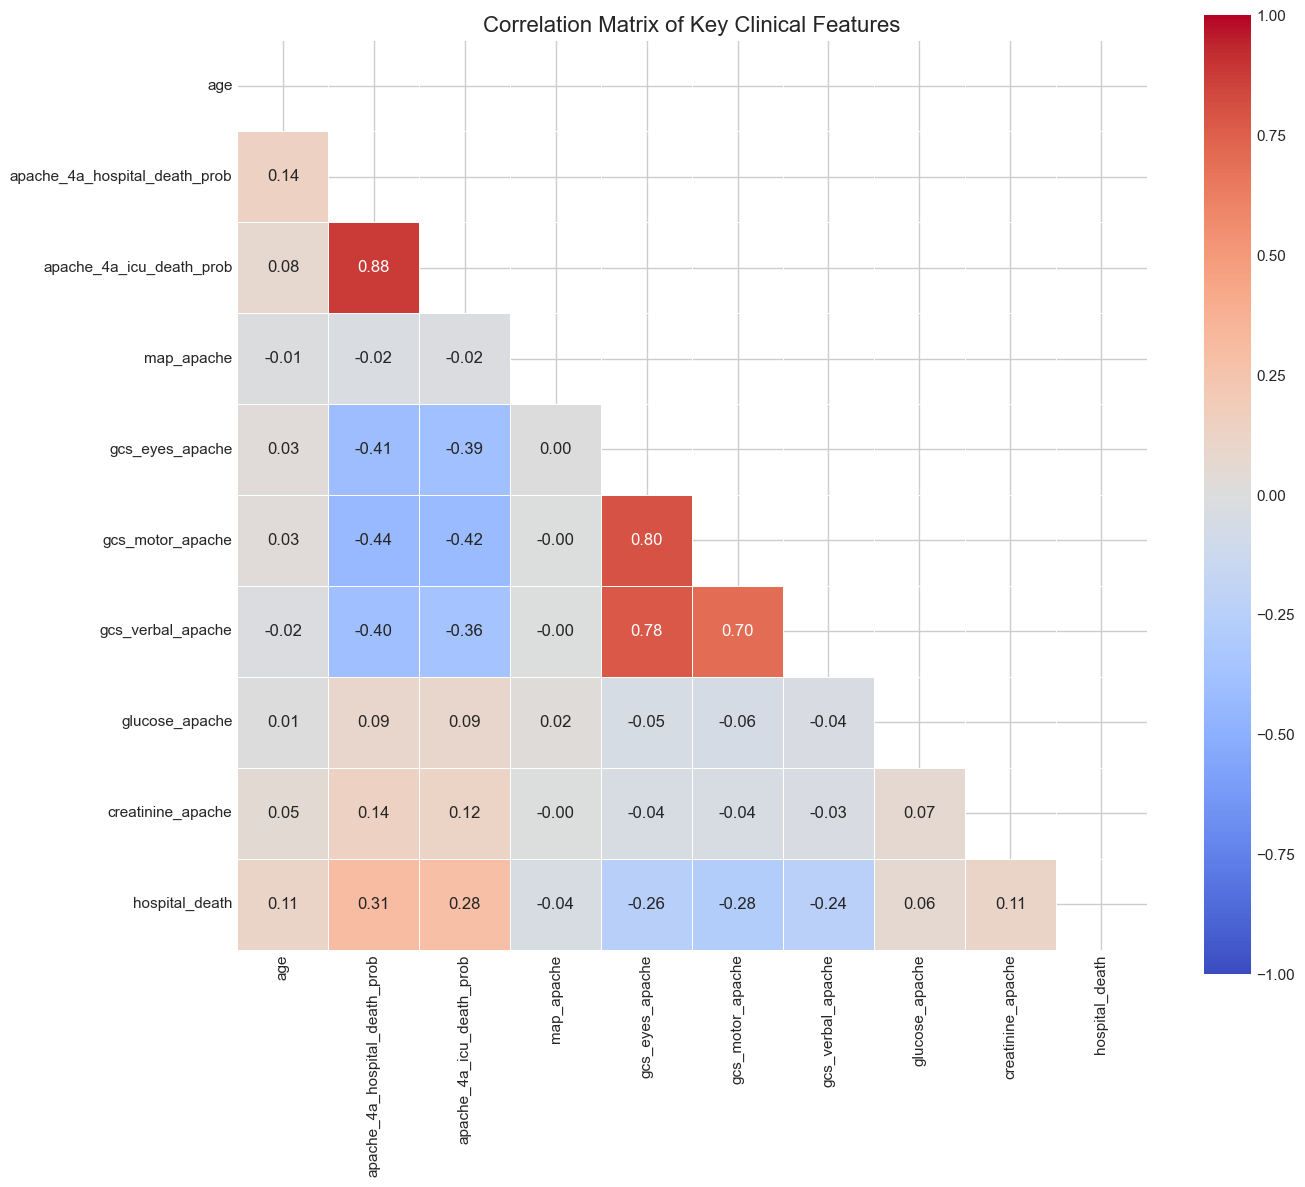

In [13]:
# Correlation analysis
if len(numerical_cols) > 0:
    # Select a subset of numeric columns that might be clinically relevant to avoid a cluttered plot
    clinical_cols = ['age', 'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob',
                     'heart_rate', 'map_apache', 'resp_rate', 'temperature', 'gcs_eyes_apache',
                     'gcs_motor_apache', 'gcs_verbal_apache', 'glucose_apache', 'creatinine_apache']
    
    # Filter to only include available columns
    available_clinical_cols = [col for col in clinical_cols if col in X_train_filtered.columns]
    
    if len(available_clinical_cols) > 0:
        # Include the target variable
        corr_data = X_train_filtered[available_clinical_cols].join(y_train)
        
        # Calculate correlation matrix
        corr_matrix = corr_data.corr()
        
        # Plot heatmap
        plt.figure(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
                   mask=mask, vmin=-1, vmax=1, center=0,
                   square=True, linewidths=.5)
        plt.title('Correlation Matrix of Key Clinical Features', fontsize=16)
        plt.tight_layout()
        plt.show()

## 4. Model Training and Evaluation

In [14]:
# Train models with different imputation strategies
pipelines, scores = {}, {}

for strategy in config.IMPUTATION_STRATEGIES:
    print(f"\nTraining model with {strategy} imputation...")
    
    # Create preprocessor
    preprocessor = dp.create_preprocessing_pipeline(
        numerical_cols, categorical_cols, strategy
    )
    
    # Create and train the pipeline
    pipeline = mdl.create_random_forest_pipeline(
        preprocessor, 
        use_class_weights=True, 
        n_estimators=config.RF_PARAMS['n_estimators'],
        max_depth=config.RF_PARAMS['max_depth'],
        min_samples_split=config.RF_PARAMS['min_samples_split'],
        random_state=config.RF_PARAMS['random_state']
    )
    
    pipeline.fit(X_train_filtered, y_train)
    
    # Evaluate
    results, y_pred, y_proba = mdl.evaluate_model(
        pipeline, X_test_filtered, y_test, f"{strategy.capitalize()} Imputation"
    )
    
    # Store pipeline and results
    pipelines[strategy] = pipeline
    scores[strategy] = results


Training model with simple imputation...
Evaluation Results - Simple Imputation:
ROC AUC: 0.889
Accuracy: 0.864
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16760
           1       0.35      0.70      0.47      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.79      0.70     18343
weighted avg       0.92      0.86      0.88     18343


Training model with median imputation...
Evaluation Results - Median Imputation:
ROC AUC: 0.889
Accuracy: 0.866
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16760
           1       0.36      0.69      0.47      1583

    accuracy                           0.87     18343
   macro avg       0.66      0.79      0.70     18343
weighted avg       0.92      0.87      0.88     18343



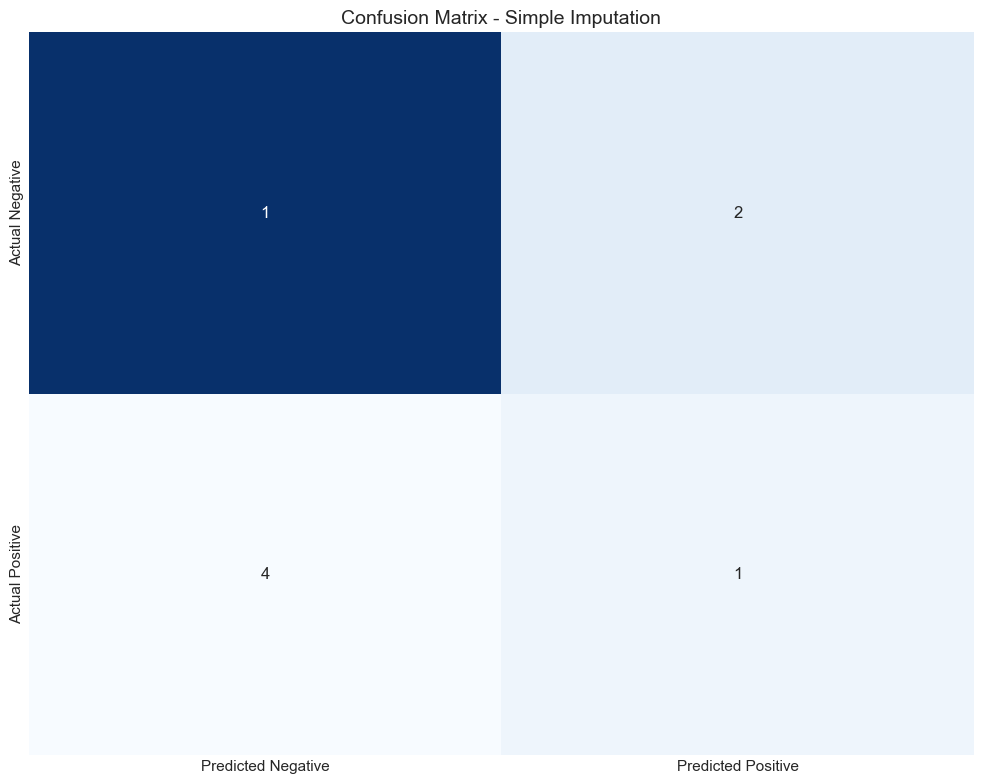

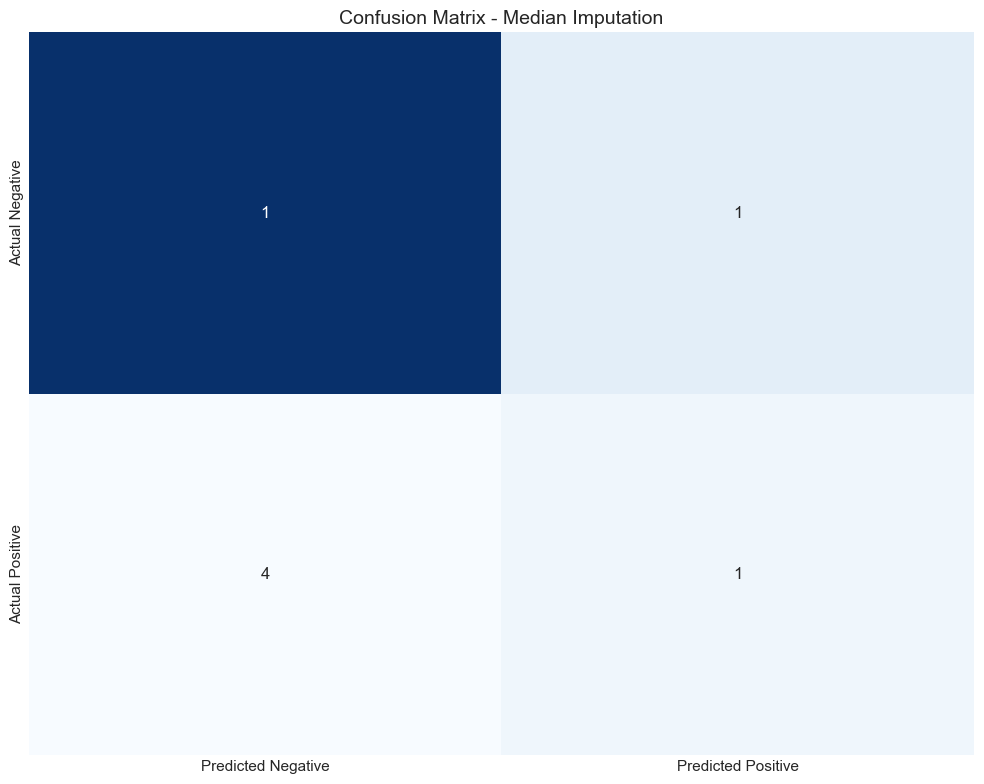

In [15]:
# Create enhanced confusion matrices for all models
for strategy, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test_filtered)
    
    # Create confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    # Calculate percentages
    cm_percent = cm / cm.sum()
    
    # Create annotations with count and percentage
    annot = np.empty_like(cm, dtype=str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1%})'
    
    # Plot heatmap
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                cbar=False)
    plt.title(f'Confusion Matrix - {strategy.capitalize()} Imputation', fontsize=14)
    plt.tight_layout()
    plt.show()

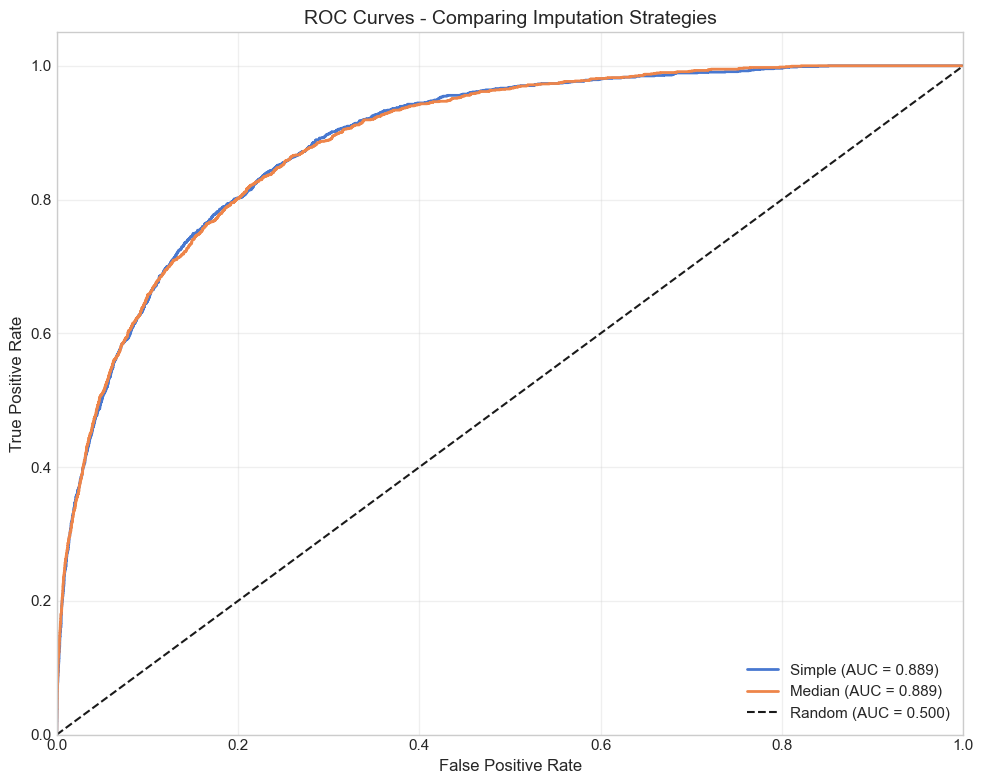

In [16]:
# Compare ROC curves for different imputation strategies
plt.figure(figsize=(10, 8))
for strategy, pipeline in pipelines.items():
    y_proba = pipeline.predict_proba(X_test_filtered)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{strategy.capitalize()} (AUC = {auc_score:.3f})')

# Add random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Comparing Imputation Strategies', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

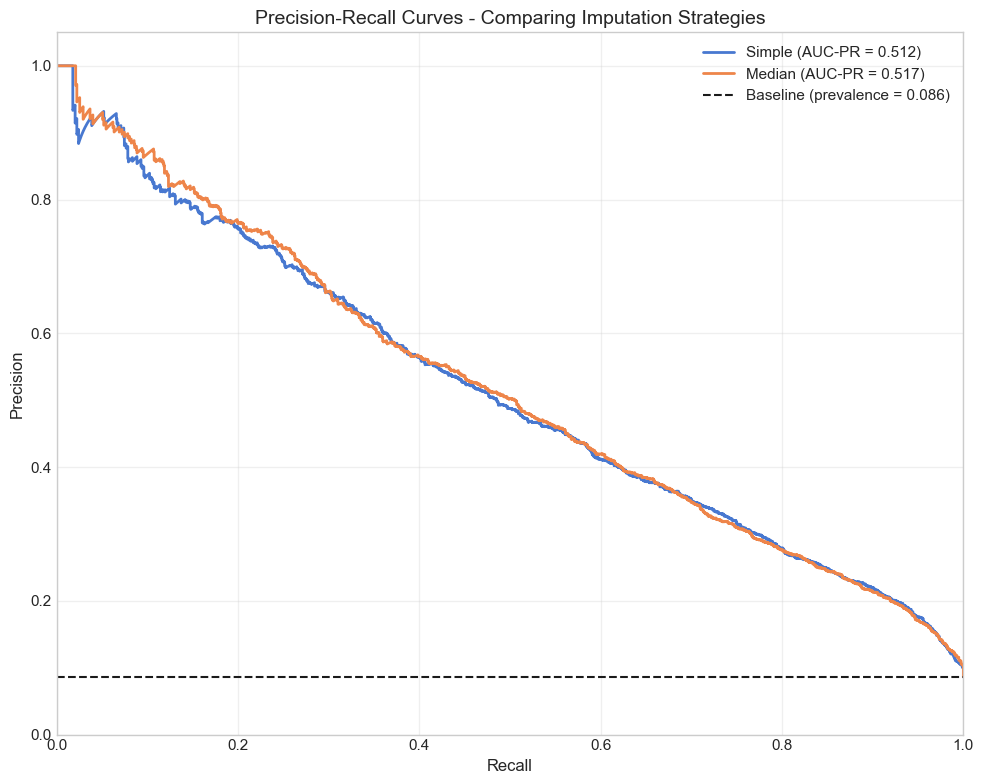

In [17]:
# Compare Precision-Recall curves for different imputation strategies
plt.figure(figsize=(10, 8))
for strategy, pipeline in pipelines.items():
    y_proba = pipeline.predict_proba(X_test_filtered)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)  # Area under the PR curve
    plt.plot(recall, precision, linewidth=2, label=f'{strategy.capitalize()} (AUC-PR = {auc_pr:.3f})')

# Add baseline based on positive class prevalence
baseline = np.mean(y_test)
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline (prevalence = {baseline:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Comparing Imputation Strategies', fontsize=14)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Find the best imputation strategy
comparison_df, best_strategy = utils.compare_models({s: scores[s] for s in config.IMPUTATION_STRATEGIES}, 'roc_auc')

print(f"Best imputation strategy: {best_strategy}")
print(comparison_df)

# Save the best model for later use
best_model = pipelines[best_strategy]
with open(os.path.join(config.MODELS_DIR, f'best_model_{best_strategy}.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

Best imputation strategy: simple
         roc_auc
simple  0.889242
median  0.888954


## 5. Feature Importance Analysis

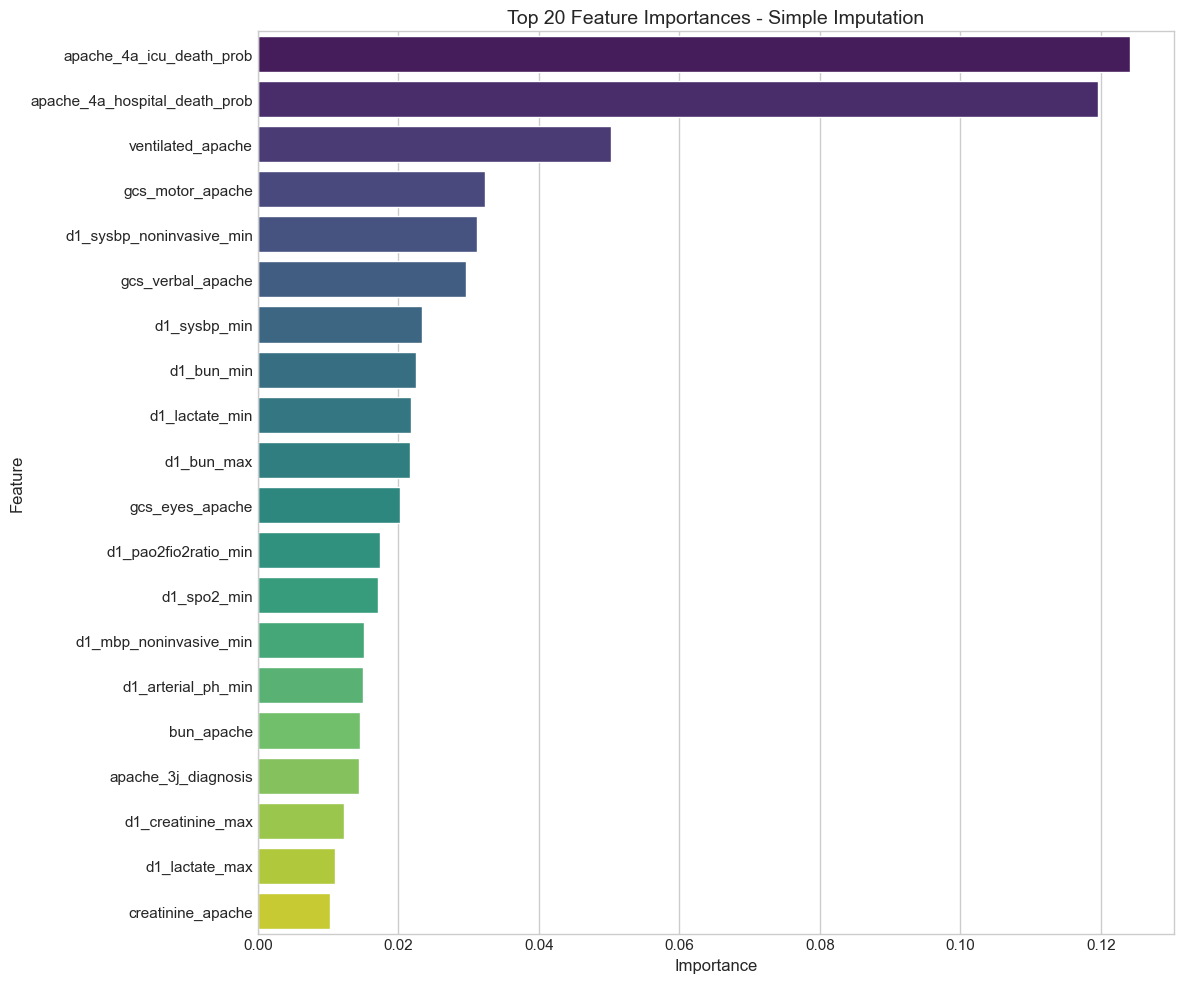

Top 20 most important features:


,Feature,Importance
134,apache_4a_icu_death_prob,0.124222
133,apache_4a_hospital_death_prob,0.119599
37,ventilated_apache,0.050314
21,gcs_motor_apache,0.032254
62,d1_sysbp_noninvasive_min,0.031119
23,gcs_verbal_apache,0.029672
60,d1_sysbp_min,0.023415
90,d1_bun_min,0.022471
106,d1_lactate_min,0.021814
89,d1_bun_max,0.021689


In [19]:
# Extract feature names and importances
feature_names = mdl.get_feature_names(pipelines[best_strategy].named_steps['preprocessor'])
feature_importances = pipelines[best_strategy].named_steps['classifier'].feature_importances_

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title(f'Top 20 Feature Importances - {best_strategy.capitalize()} Imputation', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Display feature importance table
print("Top 20 most important features:")
display(importance_df.head(20))

In [20]:
# Try to add SHAP analysis if it's available
try:
    # Create a sample of the data for SHAP analysis
    X_sample = X_test_filtered.sample(min(100, len(X_test_filtered)), random_state=42)
    
    # Create the preprocessor
    preprocessor = best_model.named_steps['preprocessor']
    X_sample_processed = preprocessor.transform(X_sample)
    
    # Create a SHAP explainer with the classifier
    classifier = best_model.named_steps['classifier']
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_sample_processed)
    
    # Plot SHAP summary
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values[1], X_sample_processed, feature_names=feature_names)
except Exception as e:
    print(f"SHAP analysis failed: {str(e)}")
    print("Continue with other analyses")

SHAP analysis failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.
Continue with other analyses


<Figure size 1200x1000 with 0 Axes>

## 6. Model Comparison with APACHE IV

APACHE IV AUC: 0.844
Our model AUC (on same subset): 0.894
Valid samples for comparison: 16787 out of 18343


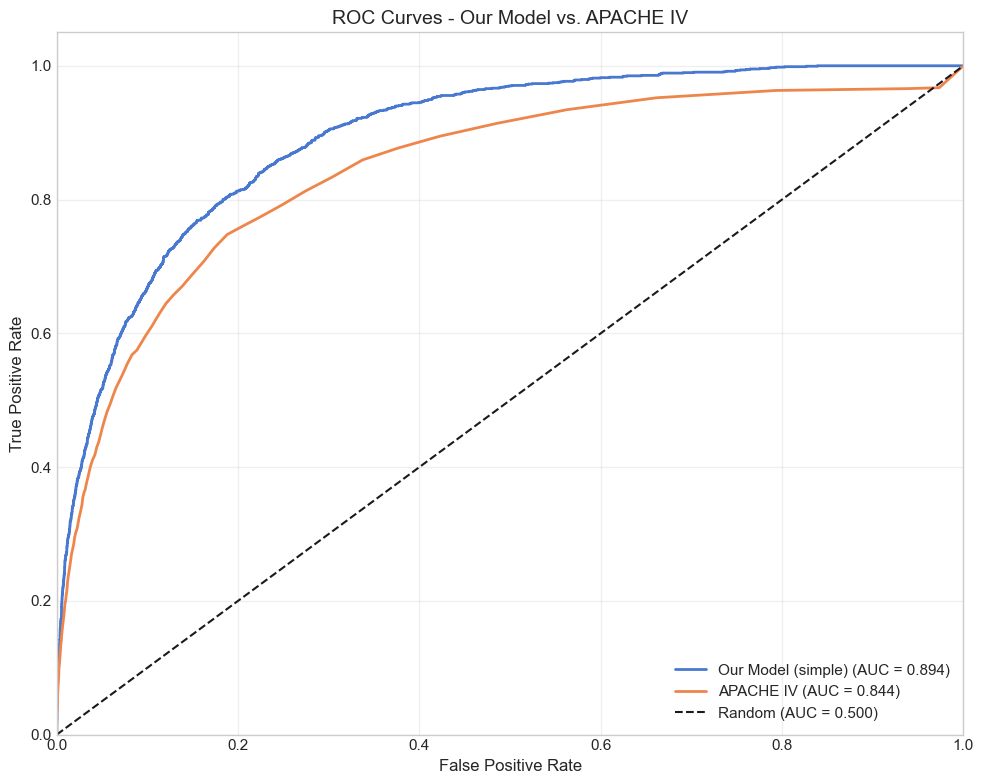

ValueError: 'list' argument must have no negative elements

<Figure size 1000x800 with 0 Axes>

In [21]:
# Compare with APACHE IV prediction if available
apache_result = mdl.compare_with_apache_iv(X_test_filtered, y_test, best_model.predict_proba(X_test_filtered)[:, 1])

if apache_result is not None:
    apache_auc, our_auc = apache_result
    
    # Plot comparison
    valid_mask = ~np.isnan(X_test_filtered['apache_4a_hospital_death_prob'].values)
    
    if np.sum(valid_mask) > 0:
        y_test_valid = y_test.iloc[valid_mask] if isinstance(y_test, pd.Series) else y_test[valid_mask]
        
        our_proba = best_model.predict_proba(
            X_test_filtered.iloc[valid_mask] if hasattr(X_test_filtered, 'iloc') else X_test_filtered[valid_mask]
        )[:, 1]
        apache_proba = X_test_filtered['apache_4a_hospital_death_prob'].values[valid_mask]
        
        # Plot ROC curves
        plt.figure(figsize=(10, 8))
        
        fpr_our, tpr_our, _ = roc_curve(y_test_valid, our_proba)
        plt.plot(fpr_our, tpr_our, linewidth=2, label=f'Our Model ({best_strategy}) (AUC = {our_auc:.3f})')
        
        fpr_apache, tpr_apache, _ = roc_curve(y_test_valid, apache_proba)
        plt.plot(fpr_apache, tpr_apache, linewidth=2, label=f'APACHE IV (AUC = {apache_auc:.3f})')
        
        plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curves - Our Model vs. APACHE IV', fontsize=14)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Create a calibration plot
        plt.figure(figsize=(10, 8))
        n_bins = 10
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        our_bins = np.digitize(our_proba, bin_edges) - 1
        our_bin_means = np.bincount(our_bins, weights=our_proba) / np.bincount(our_bins)
        our_bin_true = np.bincount(our_bins, weights=y_test_valid.astype(int)) / np.bincount(our_bins)
        
        apache_bins = np.digitize(apache_proba, bin_edges) - 1
        apache_bin_means = np.bincount(apache_bins, weights=apache_proba) / np.bincount(apache_bins)
        apache_bin_true = np.bincount(apache_bins, weights=y_test_valid.astype(int)) / np.bincount(apache_bins)
        
        plt.plot(our_bin_means, our_bin_true, 's-', label=f'Our Model ({best_strategy})')
        plt.plot(apache_bin_means, apache_bin_true, 'o-', label='APACHE IV')
        plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
        
        plt.xlabel('Mean Predicted Probability', fontsize=12)
        plt.ylabel('Fraction of Positives', fontsize=12)
        plt.title('Calibration Plot - Our Model vs. APACHE IV', fontsize=14)
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 7. Fairness Analysis

Fairness Metrics by Ethnicity:


,count,mortality_rate,prediction_rate,auc,selection_rate,true_positive_rate,false_positive_rate
Caucasian,14175,0.086349,0.172698,0.887639,0.172698,0.699346,0.122925
African American,1901,0.083640,0.164650,0.894576,0.164650,0.698113,0.115959
Other/Unknown,855,0.084211,0.163743,0.890024,0.163743,0.722222,0.112388
Hispanic,748,0.112299,0.171123,0.873655,0.171123,0.619048,0.114458
Asian,218,0.059633,0.119266,0.934709,0.119266,0.692308,0.082927
Native American,174,0.063218,0.178161,0.951478,0.178161,0.909091,0.128834


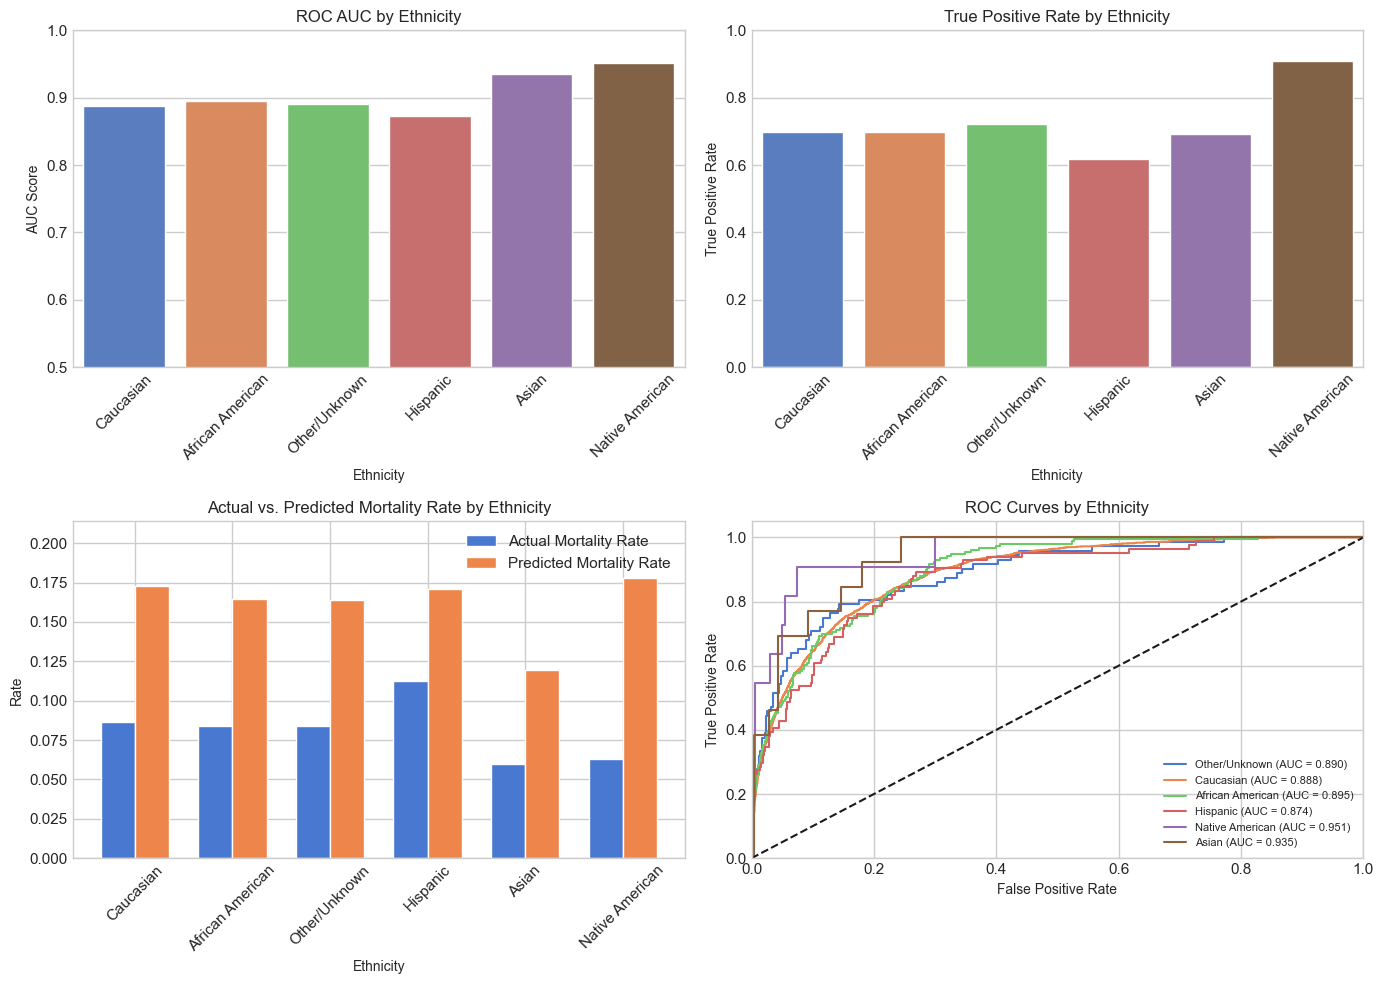

In [22]:
# Analyze model performance across different ethnic groups
best_model = pipelines[best_strategy]
y_pred = best_model.predict(X_test_filtered)
y_proba = best_model.predict_proba(X_test_filtered)[:, 1]

if 'ethnicity' in X_test_filtered.columns:
    ethnicities = X_test_filtered['ethnicity'].dropna().unique()
    fairness_metrics = {}
    tpr_dict = {}
    fpr_dict = {}
    roc_auc_dict = {}
    
    for ethnicity in ethnicities:
        ethnicity_indices = X_test_filtered['ethnicity'] == ethnicity
        if sum(ethnicity_indices) < 10:
            continue
        
        y_test_group = y_test[ethnicity_indices]
        y_pred_group = y_pred[ethnicity_indices]
        y_proba_group = y_proba[ethnicity_indices]
        
        try:
            fairness_metrics[ethnicity] = {
                'count': sum(ethnicity_indices),
                'mortality_rate': y_test_group.mean(),
                'prediction_rate': y_pred_group.mean(),
                'auc': roc_auc_score(y_test_group, y_proba_group),
                'selection_rate': selection_rate(y_test_group, y_pred_group),
                'true_positive_rate': true_positive_rate(y_test_group, y_pred_group),
                'false_positive_rate': false_positive_rate(y_test_group, y_pred_group)
            }
            fpr, tpr, _ = roc_curve(y_test_group, y_proba_group)
            tpr_dict[ethnicity] = tpr
            fpr_dict[ethnicity] = fpr
            roc_auc_dict[ethnicity] = roc_auc_score(y_test_group, y_proba_group)
        except Exception as e:
            print(f"Error calculating metrics for ethnicity '{ethnicity}': {str(e)}")
            continue
    
    fairness_df = pd.DataFrame(fairness_metrics).T
    fairness_df['count'] = fairness_df['count'].astype(int)
    fairness_df = fairness_df.sort_values('count', ascending=False)
    
    print("Fairness Metrics by Ethnicity:")
    display(fairness_df)
    
    plt.figure(figsize=(14, 10))
    
    plt.subplot(2, 2, 1)
    ax = sns.barplot(x=fairness_df.index, y=fairness_df['auc'])
    plt.title('ROC AUC by Ethnicity', fontsize=12)
    plt.ylabel('AUC Score', fontsize=10)
    plt.xlabel('Ethnicity', fontsize=10)
    plt.xticks(rotation=45)
    plt.ylim(0.5, 1.0)
    
    plt.subplot(2, 2, 2)
    ax = sns.barplot(x=fairness_df.index, y=fairness_df['true_positive_rate'])
    plt.title('True Positive Rate by Ethnicity', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=10)
    plt.xlabel('Ethnicity', fontsize=10)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.0)
    
    plt.subplot(2, 2, 3)
    width = 0.35
    x = np.arange(len(fairness_df.index))
    plt.bar(x - width/2, fairness_df['mortality_rate'], width, label='Actual Mortality Rate')
    plt.bar(x + width/2, fairness_df['prediction_rate'], width, label='Predicted Mortality Rate')
    plt.title('Actual vs. Predicted Mortality Rate by Ethnicity', fontsize=12)
    plt.xlabel('Ethnicity', fontsize=10)
    plt.ylabel('Rate', fontsize=10)
    plt.xticks(x, fairness_df.index, rotation=45)
    plt.legend(loc='best')
    plt.ylim(0, max(fairness_df['mortality_rate'].max(), fairness_df['prediction_rate'].max()) * 1.2)
    
    plt.subplot(2, 2, 4)
    for ethnicity in roc_auc_dict.keys():
        plt.plot(fpr_dict[ethnicity], tpr_dict[ethnicity], label=f'{ethnicity} (AUC = {roc_auc_dict[ethnicity]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=10)
    plt.title('ROC Curves by Ethnicity', fontsize=12)
    plt.legend(loc="lower right", fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("Ethnicity information not available in the dataset.")

## 8. Analysis by Body System

Model Performance by Body System:


,mortality_rate,count,auc,precision,recall,f1,prediction_rate
Undefined Diagnoses,0.035714,56,0.962963,0.333333,0.500000,0.400000,0.053571
Metabolic,0.018722,1549,0.917105,0.206897,0.206897,0.206897,0.018722
Trauma,0.071240,758,0.907881,0.425287,0.685185,0.524823,0.114776
Cardiovascular,0.111140,7783,0.896167,0.383862,0.769942,0.512308,0.222922
Renal/Genitourinary,0.044715,492,0.879787,0.200000,0.500000,0.285714,0.111789
Gastrointestinal,0.074197,1806,0.869720,0.354978,0.611940,0.449315,0.127907
Neurologic,0.080172,2320,0.864276,0.349845,0.607527,0.444008,0.139224
Undefined diagnoses,0.017456,802,0.846356,0.285714,0.285714,0.285714,0.017456
Respiratory,0.104471,2326,0.832963,0.286195,0.699588,0.406213,0.255374
Haematologic,0.074074,135,0.785600,0.315789,0.600000,0.413793,0.140741


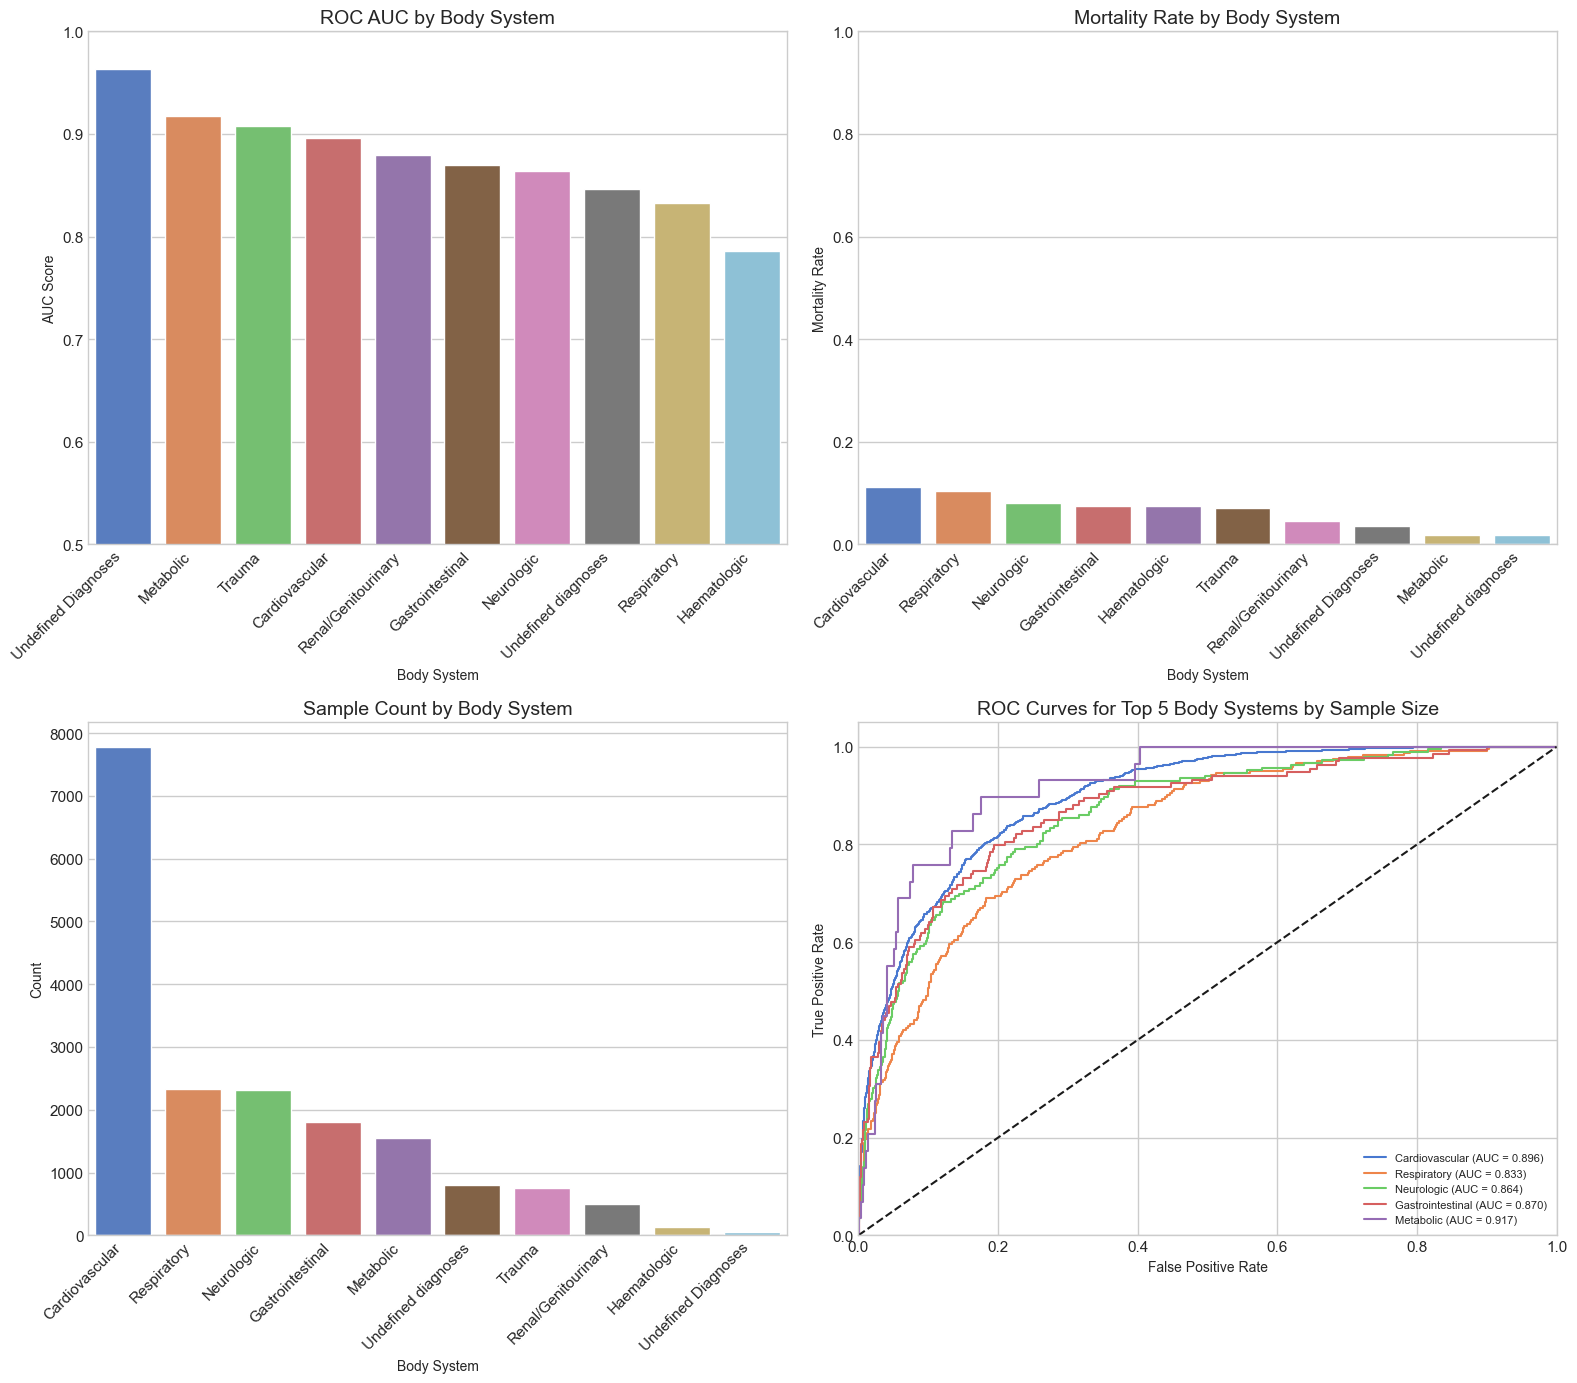

In [23]:
# Get a high-level overview of body system performance
if 'apache_2_bodysystem' in X_test_filtered.columns:
    body_system_mortality = {}
    bs_tpr_dict = {}
    bs_fpr_dict = {}
    bs_roc_auc_dict = {}
    
    for body_system in X_test_filtered['apache_2_bodysystem'].unique():
        if pd.isna(body_system):
            continue
        mask = X_test_filtered['apache_2_bodysystem'] == body_system
        if mask.sum() > 20:
            mortality_rate = y_test[mask].mean()
            count = mask.sum()
            y_pred_system = best_model.predict(X_test_filtered[mask])
            y_proba_system = best_model.predict_proba(X_test_filtered[mask])[:, 1]
            try:
                auc_system = roc_auc_score(y_test[mask], y_proba_system)
                precision_system = precision_score(y_test[mask], y_pred_system)
                recall_system = recall_score(y_test[mask], y_pred_system)
                f1_system = f1_score(y_test[mask], y_pred_system)
                fpr, tpr, _ = roc_curve(y_test[mask], y_proba_system)
                bs_tpr_dict[body_system] = tpr
                bs_fpr_dict[body_system] = fpr
                bs_roc_auc_dict[body_system] = auc_system
                body_system_mortality[body_system] = {
                    'mortality_rate': mortality_rate, 
                    'count': count,
                    'auc': auc_system,
                    'precision': precision_system,
                    'recall': recall_system,
                    'f1': f1_system,
                    'prediction_rate': y_pred_system.mean()
                }
            except Exception as e:
                print(f"Error calculating metrics for body system '{body_system}': {str(e)}")
                continue
    
    body_system_df = pd.DataFrame(body_system_mortality).T
    body_system_df['count'] = body_system_df['count'].astype(int)
    body_system_df = body_system_df.sort_values('auc', ascending=False)
    
    print("Model Performance by Body System:")
    display(body_system_df)
    
    plt.figure(figsize=(16, 14))
    
    plt.subplot(2, 2, 1)
    sns.barplot(x=body_system_df.index, y=body_system_df['auc'])
    plt.title('ROC AUC by Body System', fontsize=14)
    plt.xlabel('Body System', fontsize=10)
    plt.ylabel('AUC Score', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.0)
    
    plt.subplot(2, 2, 2)
    body_system_df_sorted = body_system_df.sort_values('mortality_rate', ascending=False)
    sns.barplot(x=body_system_df_sorted.index, y=body_system_df_sorted['mortality_rate'])
    plt.title('Mortality Rate by Body System', fontsize=14)
    plt.xlabel('Body System', fontsize=10)
    plt.ylabel('Mortality Rate', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)
    
    plt.subplot(2, 2, 3)
    body_system_df_count = body_system_df.sort_values('count', ascending=False)
    sns.barplot(x=body_system_df_count.index, y=body_system_df_count['count'])
    plt.title('Sample Count by Body System', fontsize=14)
    plt.xlabel('Body System', fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    plt.subplot(2, 2, 4)
    top_systems = body_system_df_count.head(5).index.tolist()
    for body_system in top_systems:
        if body_system in bs_roc_auc_dict:
            plt.plot(bs_fpr_dict[body_system], bs_tpr_dict[body_system], label=f'{body_system} (AUC = {bs_roc_auc_dict[body_system]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=10)
    plt.title('ROC Curves for Top 5 Body Systems by Sample Size', fontsize=14)
    plt.legend(loc="lower right", fontsize=8)
    
    plt.tight_layout()
    plt.show()

## 9. Additional Analysis: In-Depth Body System Modeling


Analyzing body system: Gastrointestinal
Training samples: 7220, Test samples: 1806
Evaluation Results - Body System: Gastrointestinal:
ROC AUC: 0.865
Accuracy: 0.933
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1672
           1       0.58      0.37      0.45       134

    accuracy                           0.93      1806
   macro avg       0.76      0.67      0.71      1806
weighted avg       0.92      0.93      0.93      1806


Analyzing body system: Cardiovascular
Training samples: 31033, Test samples: 7783
Evaluation Results - Body System: Cardiovascular:
ROC AUC: 0.898
Accuracy: 0.875
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6918
           1       0.46      0.68      0.55       865

    accuracy                           0.87      7783
   macro avg       0.71      0.79      0.74      7783
weighted avg       0.90 

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Evaluation Results - Body System: Undefined diagnoses:
ROC AUC: 0.875
Accuracy: 0.983
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       788
           1       0.00      0.00      0.00        14

    accuracy                           0.98       802
   macro avg       0.49      0.50      0.50       802
weighted avg       0.97      0.98      0.97       802


Analyzing body system: Neurologic
Training samples: 9576, Test samples: 2320
Evaluation Results - Body System: Neurologic:
ROC AUC: 0.880
Accuracy: 0.910
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2134
           1       0.44      0.46      0.45       186

    accuracy                           0.91      2320
   macro avg       0.70      0.70      0.70      2320
weighted avg       0.91      0.91      0.91      2320


Analyzing body system: Respiratory
Training samples: 9283,

C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\klaem\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

,AUC
Cardiovascular,0.897912
Trauma,0.886521
Neurologic,0.880257
Undefined diagnoses,0.875272
Metabolic,0.870349
Gastrointestinal,0.865248
Renal/Genitourinary,0.848162
Undefined Diagnoses,0.842593
Respiratory,0.829938
Haematologic,0.795200



Comparing Overall vs. Specialized Models by Body System:


,Overall Model AUC,Specialized Model AUC,Improvement
Undefined diagnoses,0.846356,0.875272,0.028916
Neurologic,0.864276,0.880257,0.015980
Haematologic,0.785600,0.795200,0.009600
Cardiovascular,0.896167,0.897912,0.001745
Respiratory,0.832963,0.829938,-0.003025
Gastrointestinal,0.869720,0.865248,-0.004472
Trauma,0.907881,0.886521,-0.021359
Renal/Genitourinary,0.879787,0.848162,-0.031625
Metabolic,0.917105,0.870349,-0.046756
Undefined Diagnoses,0.962963,0.842593,-0.120370


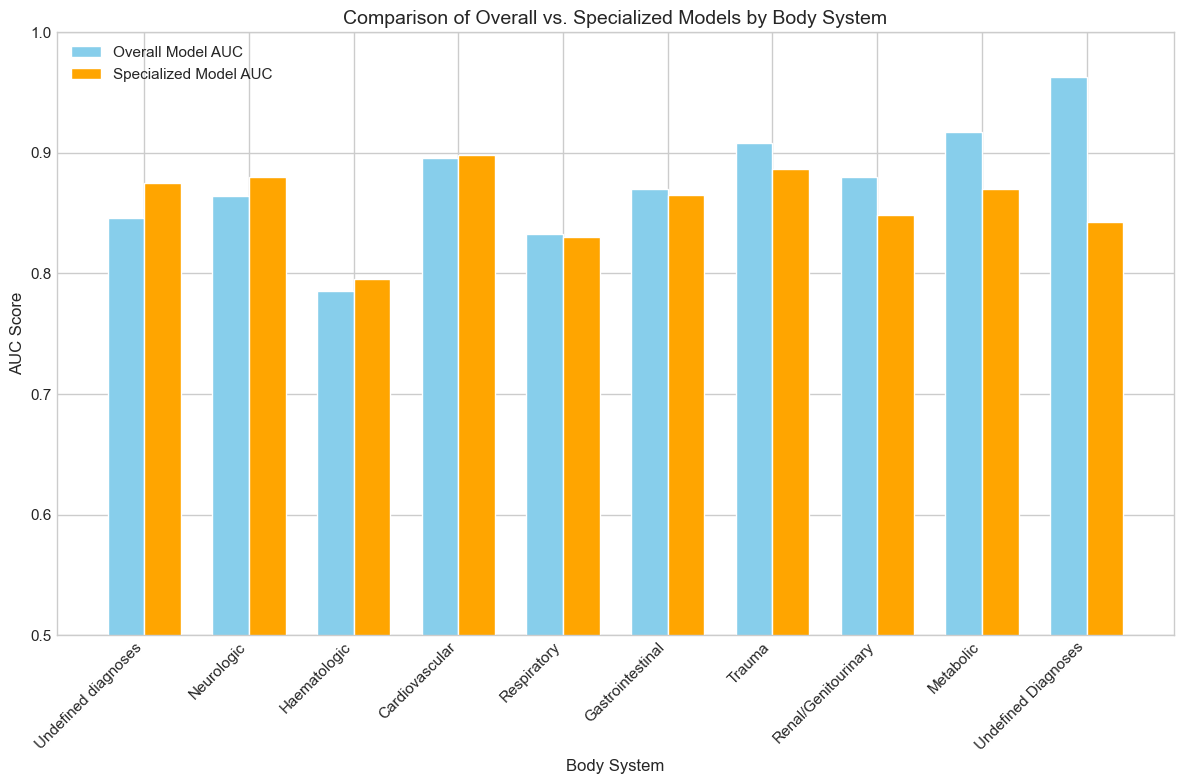


Top 10 important features for Cardiovascular:


,Feature,Importance
134,apache_4a_icu_death_prob,0.089728
133,apache_4a_hospital_death_prob,0.069297
23,gcs_verbal_apache,0.054226
21,gcs_motor_apache,0.039811
37,ventilated_apache,0.036805
20,gcs_eyes_apache,0.026739
60,d1_sysbp_min,0.024171
106,d1_lactate_min,0.024155
105,d1_lactate_max,0.022876
90,d1_bun_min,0.022317


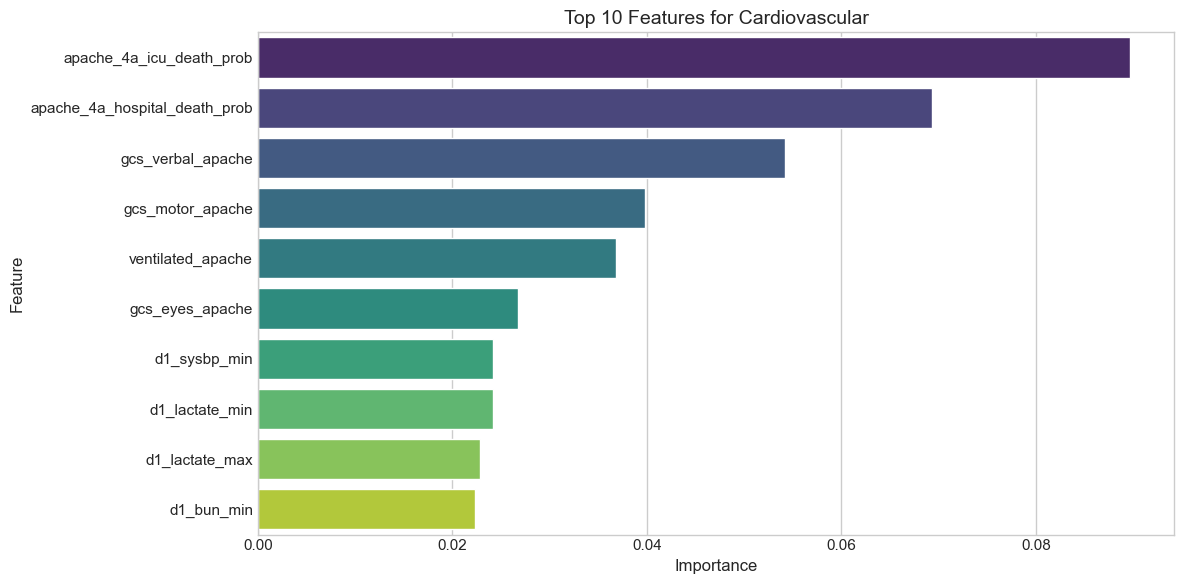

In [24]:
# Perform a more detailed analysis by body system using the analyze_by_body_system function
body_system_results = mdl.analyze_by_body_system(
    X_train_filtered, y_train, 
    X_test_filtered, y_test, 
    numerical_cols, categorical_cols, 
    best_strategy
)

if body_system_results is not None and len(body_system_results) > 0:
    body_system_auc = {system: results['results']['roc_auc'] for system, results in body_system_results.items()}
    auc_df = pd.DataFrame({'AUC': body_system_auc}).sort_values('AUC', ascending=False)
    print("\nAUC Scores for Models Trained Specifically for Each Body System:")
    display(auc_df)
    
    if 'body_system_df' in locals() and len(body_system_df) > 0:
        comparison_df = pd.DataFrame()
        comparison_df['Overall Model AUC'] = body_system_df['auc']
        specialized_aucs = {}
        for system in body_system_df.index:
            if system in auc_df.index:
                specialized_aucs[system] = auc_df.loc[system, 'AUC']
        comparison_df['Specialized Model AUC'] = pd.Series(specialized_aucs)
        comparison_df['Improvement'] = comparison_df['Specialized Model AUC'] - comparison_df['Overall Model AUC']
        comparison_df = comparison_df.sort_values('Improvement', ascending=False)
        
        print("\nComparing Overall vs. Specialized Models by Body System:")
        display(comparison_df)
        
        plt.figure(figsize=(12, 8))
        comparison_df_plot = comparison_df.dropna().head(10)
        x = np.arange(len(comparison_df_plot.index))
        width = 0.35
        plt.bar(x - width/2, comparison_df_plot['Overall Model AUC'], width, label='Overall Model AUC', color='skyblue')
        plt.bar(x + width/2, comparison_df_plot['Specialized Model AUC'], width, label='Specialized Model AUC', color='orange')
        plt.xlabel('Body System', fontsize=12)
        plt.ylabel('AUC Score', fontsize=12)
        plt.title('Comparison of Overall vs. Specialized Models by Body System', fontsize=14)
        plt.xticks(x, comparison_df_plot.index, rotation=45, ha='right')
        plt.legend()
        plt.ylim(0.5, 1.0)
        plt.tight_layout()
        plt.show()
    
    if len(auc_df) > 0:
        top_system = auc_df.index[0]
        print(f"\nTop 10 important features for {top_system}:")
        feature_importances = body_system_results[top_system]['feature_importances']
        feature_names_subset = feature_names[:len(feature_importances)]
        importance_df = pd.DataFrame({
            'Feature': feature_names_subset,
            'Importance': feature_importances
        }).sort_values('Importance', ascending=False).head(10)
        display(importance_df)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
        plt.title(f'Top 10 Features for {top_system}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()

## 10. Finding Optimal Classification Threshold

Optimal threshold: 0.611 (F1: 0.501)
Balanced threshold: 0.649 (Precision = 0.493, Recall = 0.493)

Performance with optimal threshold (maximizing F1):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     16760
           1       0.46      0.56      0.50      1583

    accuracy                           0.90     18343
   macro avg       0.71      0.75      0.72     18343
weighted avg       0.91      0.90      0.91     18343


Performance with balanced threshold (equal precision and recall):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     16760
           1       0.49      0.49      0.49      1583

    accuracy                           0.91     18343
   macro avg       0.72      0.72      0.72     18343
weighted avg       0.91      0.91      0.91     18343



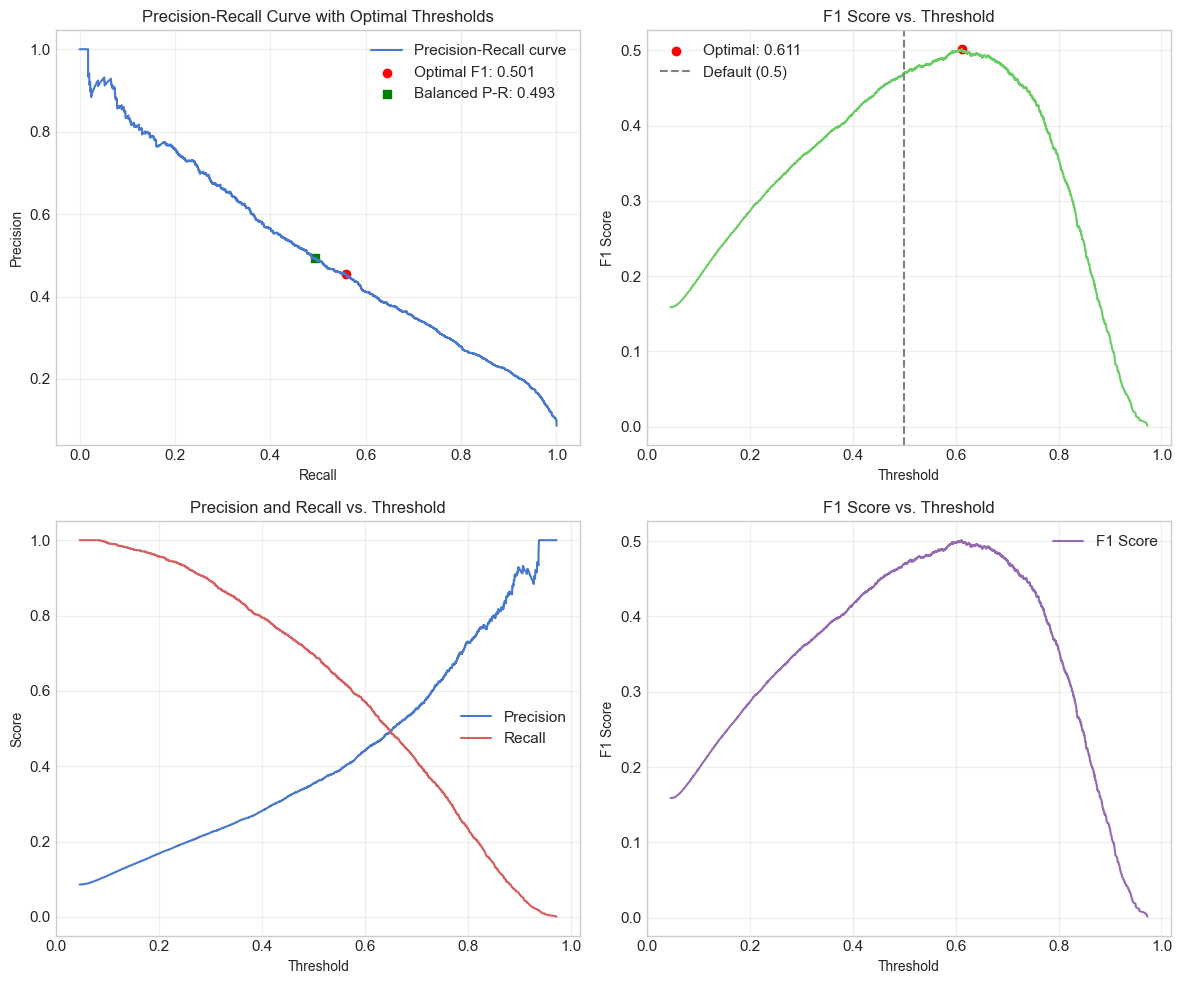

In [25]:
# Find the optimal classification threshold for our best model
from sklearn.metrics import precision_recall_curve, f1_score

y_proba = best_model.predict_proba(X_test_filtered)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = []
for threshold in thresholds:
    y_pred_temp = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    f1_scores.append(f1)

best_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

print(f"Optimal threshold: {optimal_threshold:.3f} (F1: {best_f1:.3f})")

balanced_idx = np.argmin(np.abs(precision[:-1] - recall[:-1]))
balanced_threshold = thresholds[balanced_idx]
balanced_precision = precision[balanced_idx]
balanced_recall = recall[balanced_idx]

print(f"Balanced threshold: {balanced_threshold:.3f} (Precision = {balanced_precision:.3f}, Recall = {balanced_recall:.3f})")

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print("\nPerformance with optimal threshold (maximizing F1):")
print(classification_report(y_test, y_pred_optimal))

y_pred_balanced = (y_proba >= balanced_threshold).astype(int)
print("\nPerformance with balanced threshold (equal precision and recall):")
print(classification_report(y_test, y_pred_balanced))

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(recall, precision, 'b-', label='Precision-Recall curve')
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], marker='o', color='red', label=f'Optimal F1: {best_f1:.3f}')
plt.scatter(balanced_recall, balanced_precision, marker='s', color='green', label=f'Balanced P-R: {(balanced_precision + balanced_recall)/2:.3f}')
plt.xlabel('Recall', fontsize=10)
plt.ylabel('Precision', fontsize=10)
plt.title('Precision-Recall Curve with Optimal Thresholds', fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(thresholds, f1_scores, 'g-')
plt.scatter(optimal_threshold, best_f1, marker='o', color='red', label=f'Optimal: {optimal_threshold:.3f}')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.xlabel('Threshold', fontsize=10)
plt.ylabel('F1 Score', fontsize=10)
plt.title('F1 Score vs. Threshold', fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(thresholds, precision[:-1], 'b-', label='Precision')
plt.plot(thresholds, recall[:-1], 'r-', label='Recall')
plt.xlabel('Threshold', fontsize=10)
plt.ylabel('Score', fontsize=10)
plt.title('Precision and Recall vs. Threshold', fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(thresholds, f1_scores, 'm-', label='F1 Score')
plt.xlabel('Threshold', fontsize=10)
plt.ylabel('F1 Score', fontsize=10)
plt.title('F1 Score vs. Threshold', fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()